# Experiment 3: 2D Learnable Frequency Mask - AlexNet

## Overview

**Research Question:** Which frequency components does AlexNet rely on for classification?

**Approach:** Input Image → FFT → Learnable 2D Frequency Mask → IFFT → Frozen AlexNet

**Key Details:**
- **Frequency Mask:** 50,176 learnable parameters (224×224 spatial mask)
- **Classifier:** Pre-trained AlexNet (frozen, provides gradients)
- **Dataset:** ImageNet validation subset (10,000 images)
- **Training:** Only the frequency mask is trained

**Expected Outcome:** Learn which frequencies AlexNet prefers for accurate classification

---

## 1. Setup and Imports

In [1]:
import sys
import os

# Add project root to path
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/bab61wot/VIT/SIM2REAL


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Import project modules
from models.alexnet import load_alexnet
from frequency.pipeline import FrequencyFilterPipeline

print("✓ Imports successful")

✓ Imports successful


In [3]:
# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: NVIDIA GeForce GTX 1060 6GB
Memory: 6.36 GB


## 2. Load Dataset

Loading the pre-cached ImageNet subset (10,000 images)

In [4]:
from datasets import load_from_disk
from torchvision import transforms
from data.dataset import HFImageNetDataset

# Configuration
CACHE_PATH = os.path.join(PROJECT_ROOT, "data", "imagenet_25k_cache")
BATCH_SIZE = 64

print(f"Loading dataset from {CACHE_PATH}...")
imagenet_subset = load_from_disk(CACHE_PATH)
print(f"✓ Loaded {len(imagenet_subset):,} images")

# Setup transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Create PyTorch dataset and dataloader
dataset = HFImageNetDataset(imagenet_subset, transform=transform)
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,  # Set to 0 to avoid temp file cleanup errors
    pin_memory=True
)

print(f"✓ DataLoader created: {len(dataloader)} batches of {BATCH_SIZE}")

Loading dataset from /home/bab61wot/VIT/SIM2REAL/data/imagenet_25k_cache...
✓ Loaded 25,000 images
✓ DataLoader created: 391 batches of 64


## 3. Load AlexNet Model

Loading pre-trained AlexNet (will be frozen during training)

In [5]:
print("Loading AlexNet...")
classifier = load_alexnet(device=device)
print("✓ AlexNet loaded")

# Count parameters
total_params = sum(p.numel() for p in classifier.parameters())
print(f"  Total parameters: {total_params:,}")

Loading AlexNet...
Loading AlexNet...
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /home/bab61wot/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|████████████████████████████████████████████| 233M/233M [00:02<00:00, 107MB/s]


  ✓ Loaded pre-trained ImageNet weights
  ✓ Model moved to cuda
  ✓ Model set to eval mode
  ✓ Total parameters: 61,100,840
✓ AlexNet loaded
  Total parameters: 61,100,840


## 4. Test Baseline Accuracy

Measure AlexNet accuracy on unmodified images

In [6]:
print("Testing baseline accuracy...")
classifier.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in tqdm(dataloader, desc="Baseline test"):
        images, labels = images.to(device), labels.to(device)
        outputs = classifier(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

baseline_accuracy = 100.0 * correct / total
print(f"\n{'='*60}")
print(f"Baseline Accuracy: {baseline_accuracy:.2f}%")
print(f"Correct: {correct:,} / {total:,}")
print(f"{'='*60}")

Testing baseline accuracy...


Baseline test: 100%|█████████████████████████████| 391/391 [01:50<00:00,  3.55it/s]


Baseline Accuracy: 52.48%
Correct: 13,119 / 25,000


## 5. Create Frequency Filter Pipeline

Pipeline: Image → FFT → Learnable 2D Mask (224×224) → IFFT → Classifier

The pipeline will create the frequency mask internally with 50,176 parameters.

In [7]:
print("Creating Frequency Filter Pipeline...")
pipeline = FrequencyFilterPipeline(
    classifier=classifier,
    mask_config={
        'image_size': 224,
        'init_value': 1.0,  # Start near identity (no modification)
        'init_std': 0.1     # Small random initialization
    }
).to(device)

# Verify classifier is frozen and mask is trainable
trainable_classifier = sum(p.numel() for p in classifier.parameters() if p.requires_grad)
trainable_mask = sum(p.numel() for p in pipeline.freq_mask.parameters() if p.requires_grad)

print("\n✓ Pipeline verification:")
print(f"  Classifier trainable params: {trainable_classifier:,}")
print(f"  Mask trainable params: {trainable_mask:,}")
print(f"  Mask resolution: 224×224")

Creating Frequency Filter Pipeline...

FrequencyFilterPipeline created:
  Classifier: Frozen (0 trainable params)
  Frequency mask: 50,176 trainable params

✓ Pipeline verification:
  Classifier trainable params: 0
  Mask trainable params: 50,176
  Mask resolution: 224×224


## 6. Visualize Initial Mask

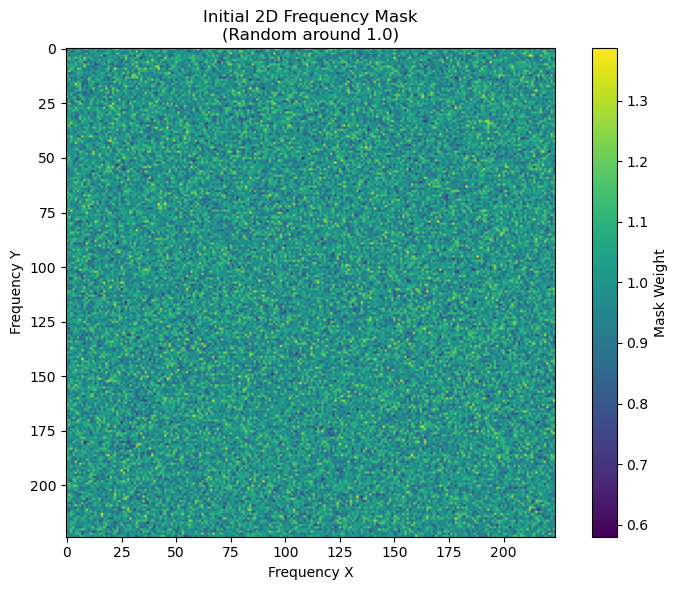

Initial mask statistics:
  Mean: 0.9999
  Std:  0.0999
  Min:  0.5802
  Max:  1.3873


In [8]:
# Get initial mask from pipeline
initial_mask = pipeline.freq_mask.get_mask_visualization()

plt.figure(figsize=(8, 6))
plt.imshow(initial_mask, cmap='viridis')
plt.colorbar(label='Mask Weight')
plt.title('Initial 2D Frequency Mask\n(Random around 1.0)', fontsize=12)
plt.xlabel('Frequency X')
plt.ylabel('Frequency Y')
plt.tight_layout()
plt.show()

print(f"Initial mask statistics:")
print(f"  Mean: {initial_mask.mean():.4f}")
print(f"  Std:  {initial_mask.std():.4f}")
print(f"  Min:  {initial_mask.min():.4f}")
print(f"  Max:  {initial_mask.max():.4f}")

## 7. Training Configuration

In [9]:
# Training hyperparameters - FIXED for stable training!
EPOCHS = 20
LEARNING_RATE = 0.01  # Much lower! (was 0.05 - 50x reduction)
WEIGHT_DECAY = 0.0     # Removed! (was 1e-4 - pushes mask toward 0)

# Setup optimizer (only train the frequency mask!)
optimizer = optim.Adam(
    pipeline.freq_mask.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)
criterion = nn.CrossEntropyLoss()

print("Training Configuration:")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE} (STABLE - was 0.05)")
print(f"  Weight decay: {WEIGHT_DECAY} (REMOVED - was 1e-4)")
print(f"  Optimizer: Adam")
print(f"  Loss: CrossEntropyLoss")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Total batches per epoch: {len(dataloader)}")
print("\n⚠️ Expected behavior:")
print("  - Loss should DECREASE each epoch")
print("  - Accuracy should INCREASE gradually")  
print("  - Mask mean should stay close to 1.0")
print("  - If accuracy drops, stop training immediately!")

Training Configuration:
  Epochs: 20
  Learning rate: 0.01 (STABLE - was 0.05)
  Weight decay: 0.0 (REMOVED - was 1e-4)
  Optimizer: Adam
  Loss: CrossEntropyLoss
  Batch size: 64
  Total batches per epoch: 391

⚠️ Expected behavior:
  - Loss should DECREASE each epoch
  - Accuracy should INCREASE gradually
  - Mask mean should stay close to 1.0
  - If accuracy drops, stop training immediately!


## 8. Training Loop

Train only the frequency mask while keeping AlexNet frozen

In [10]:
# Training history
history = {
    'train_loss': [],
    'train_acc': [],
}

print("\n" + "="*60)
print("Starting Training")
print("="*60)

for epoch in range(EPOCHS):
    pipeline.train()
    epoch_loss = 0.0
    correct = 0
    total = 0
    
    # Progress bar
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for batch_idx, (images, labels) in enumerate(pbar):
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs, reconstructed = pipeline(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Track metrics
        epoch_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # Update progress bar
        if batch_idx % 10 == 0:
            pbar.set_postfix({
                'loss': f"{loss.item():.4f}",
                'acc': f"{100.0*correct/total:.2f}%"
            })
    
    # Epoch summary
    avg_loss = epoch_loss / len(dataloader)
    accuracy = 100.0 * correct / total
    
    history['train_loss'].append(avg_loss)
    history['train_acc'].append(accuracy)
    
    print(f"\nEpoch {epoch+1}/{EPOCHS} Summary:")
    print(f"  Loss: {avg_loss:.4f}")
    print(f"  Accuracy: {accuracy:.2f}% ({correct}/{total})")
    print(f"  Baseline: {baseline_accuracy:.2f}%")
    print(f"  Improvement: {accuracy - baseline_accuracy:+.2f}%")
    print("-" * 60)

print("\n" + "="*60)
print("Training Complete!")
print("="*60)
print(f"Final Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"Baseline Accuracy: {baseline_accuracy:.2f}%")
print(f"Total Improvement: {history['train_acc'][-1] - baseline_accuracy:+.2f}%")


Starting Training


Epoch 1/20: 100%|███████| 391/391 [02:01<00:00,  3.22it/s, loss=3.5891, acc=47.40%]



Epoch 1/20 Summary:
  Loss: 2.4101
  Accuracy: 47.40% (11849/25000)
  Baseline: 52.48%
  Improvement: -5.08%
------------------------------------------------------------


Epoch 2/20: 100%|███████| 391/391 [01:54<00:00,  3.40it/s, loss=3.5363, acc=47.78%]



Epoch 2/20 Summary:
  Loss: 2.3978
  Accuracy: 47.78% (11944/25000)
  Baseline: 52.48%
  Improvement: -4.70%
------------------------------------------------------------


...


Epoch 18/20 Summary:
  Loss: 2.3856
  Accuracy: 47.72% (11929/25000)
  Baseline: 52.48%
  Improvement: -4.76%
------------------------------------------------------------


Epoch 19/20: 100%|██████| 391/391 [01:56<00:00,  3.37it/s, loss=3.5274, acc=47.96%]



Epoch 19/20 Summary:
  Loss: 2.3727
  Accuracy: 47.96% (11989/25000)
  Baseline: 52.48%
  Improvement: -4.52%
------------------------------------------------------------


Epoch 20/20: 100%|██████| 391/391 [01:56<00:00,  3.37it/s, loss=3.1755, acc=47.48%]


Epoch 20/20 Summary:
  Loss: 2.3886
  Accuracy: 47.48% (11869/25000)
  Baseline: 52.48%
  Improvement: -5.00%
------------------------------------------------------------

Training Complete!
Final Accuracy: 47.48%
Baseline Accuracy: 52.48%
Total Improvement: -5.00%


## 9. Visualize Training History

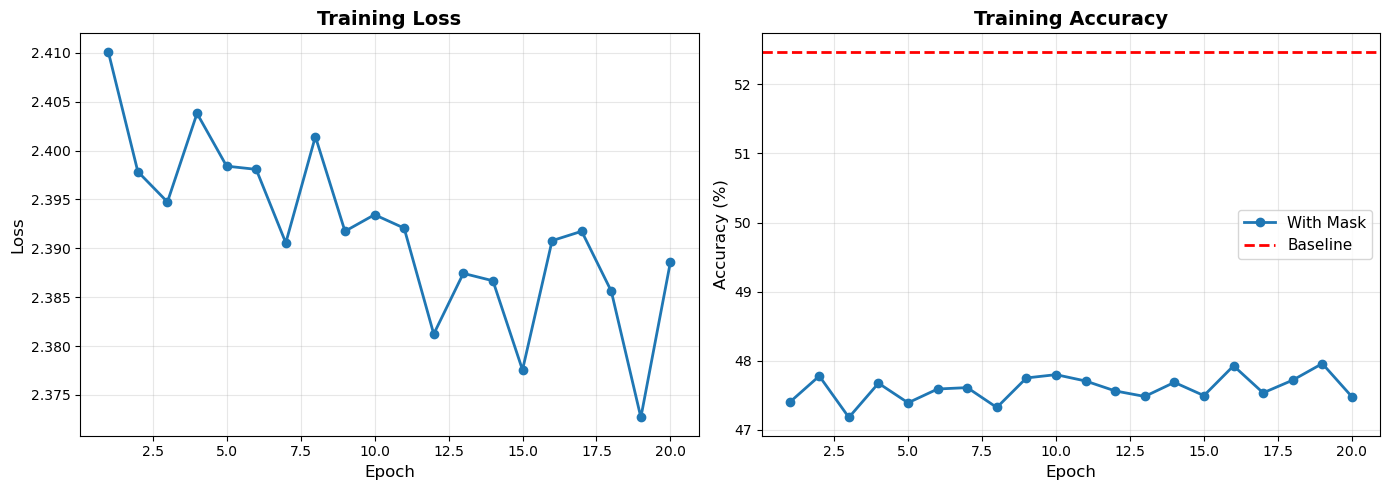

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss
ax1.plot(range(1, EPOCHS+1), history['train_loss'], marker='o', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training Loss', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Plot accuracy
ax2.plot(range(1, EPOCHS+1), history['train_acc'], marker='o', linewidth=2, label='With Mask')
ax2.axhline(y=baseline_accuracy, color='r', linestyle='--', linewidth=2, label='Baseline')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Visualize Learned Frequency Mask

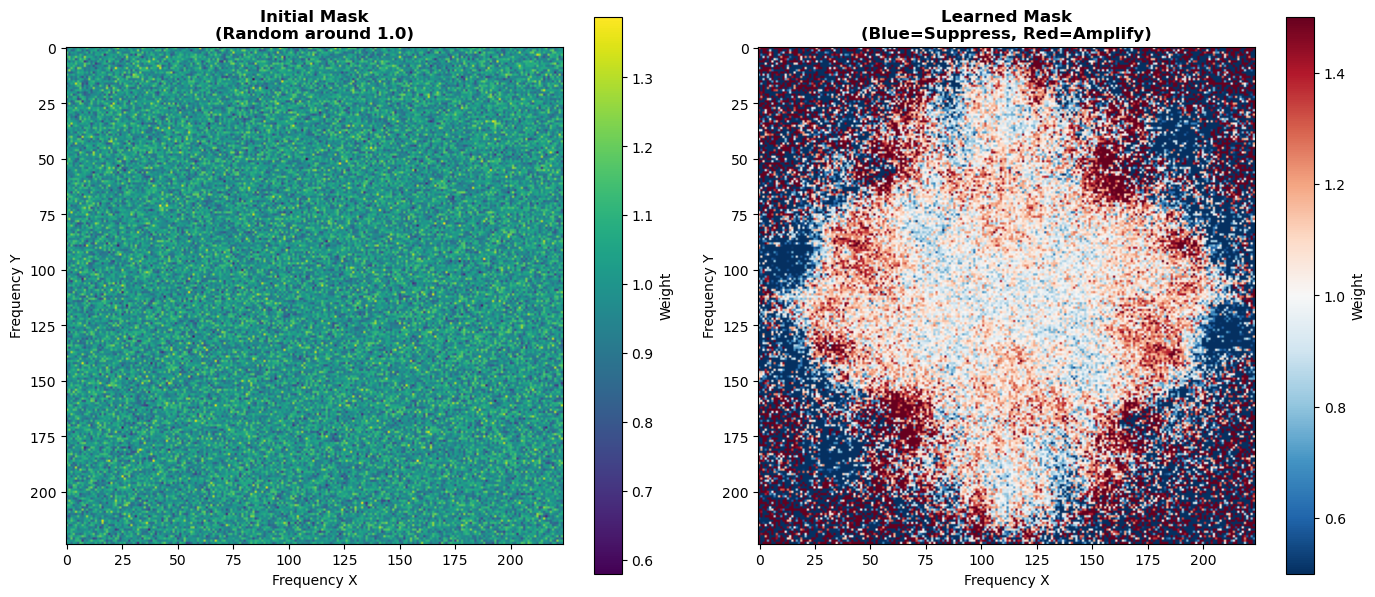


Learned mask statistics:
  Mean: 0.9292
  Std:  0.9745
  Min:  -7.5449
  Max:  8.4654

Frequency preference:
  Center (low freq): 0.9881
  Edges (high freq): 0.7827
  Preference: Low frequencies


In [13]:
# Get learned mask
learned_mask = pipeline.freq_mask.get_mask_visualization()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Initial mask
im1 = ax1.imshow(initial_mask, cmap='viridis')
ax1.set_title('Initial Mask\n(Random around 1.0)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Frequency X')
ax1.set_ylabel('Frequency Y')
plt.colorbar(im1, ax=ax1, label='Weight')

# Learned mask
im2 = ax2.imshow(learned_mask, cmap='RdBu_r', vmin=0.5, vmax=1.5)
ax2.set_title('Learned Mask\n(Blue=Suppress, Red=Amplify)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Frequency X')
ax2.set_ylabel('Frequency Y')
plt.colorbar(im2, ax=ax2, label='Weight')

plt.tight_layout()
plt.show()

print(f"\nLearned mask statistics:")
print(f"  Mean: {learned_mask.mean():.4f}")
print(f"  Std:  {learned_mask.std():.4f}")
print(f"  Min:  {learned_mask.min():.4f}")
print(f"  Max:  {learned_mask.max():.4f}")

# Analyze center vs edges
center = learned_mask[112-20:112+20, 112-20:112+20].mean()
edges = np.concatenate([
    learned_mask[0:20, :].flatten(),
    learned_mask[-20:, :].flatten(),
    learned_mask[:, 0:20].flatten(),
    learned_mask[:, -20:].flatten()
]).mean()

print(f"\nFrequency preference:")
print(f"  Center (low freq): {center:.4f}")
print(f"  Edges (high freq): {edges:.4f}")
print(f"  Preference: {'Low frequencies' if center > edges else 'High frequencies'}")

## 11. Visualize Reconstructed Images

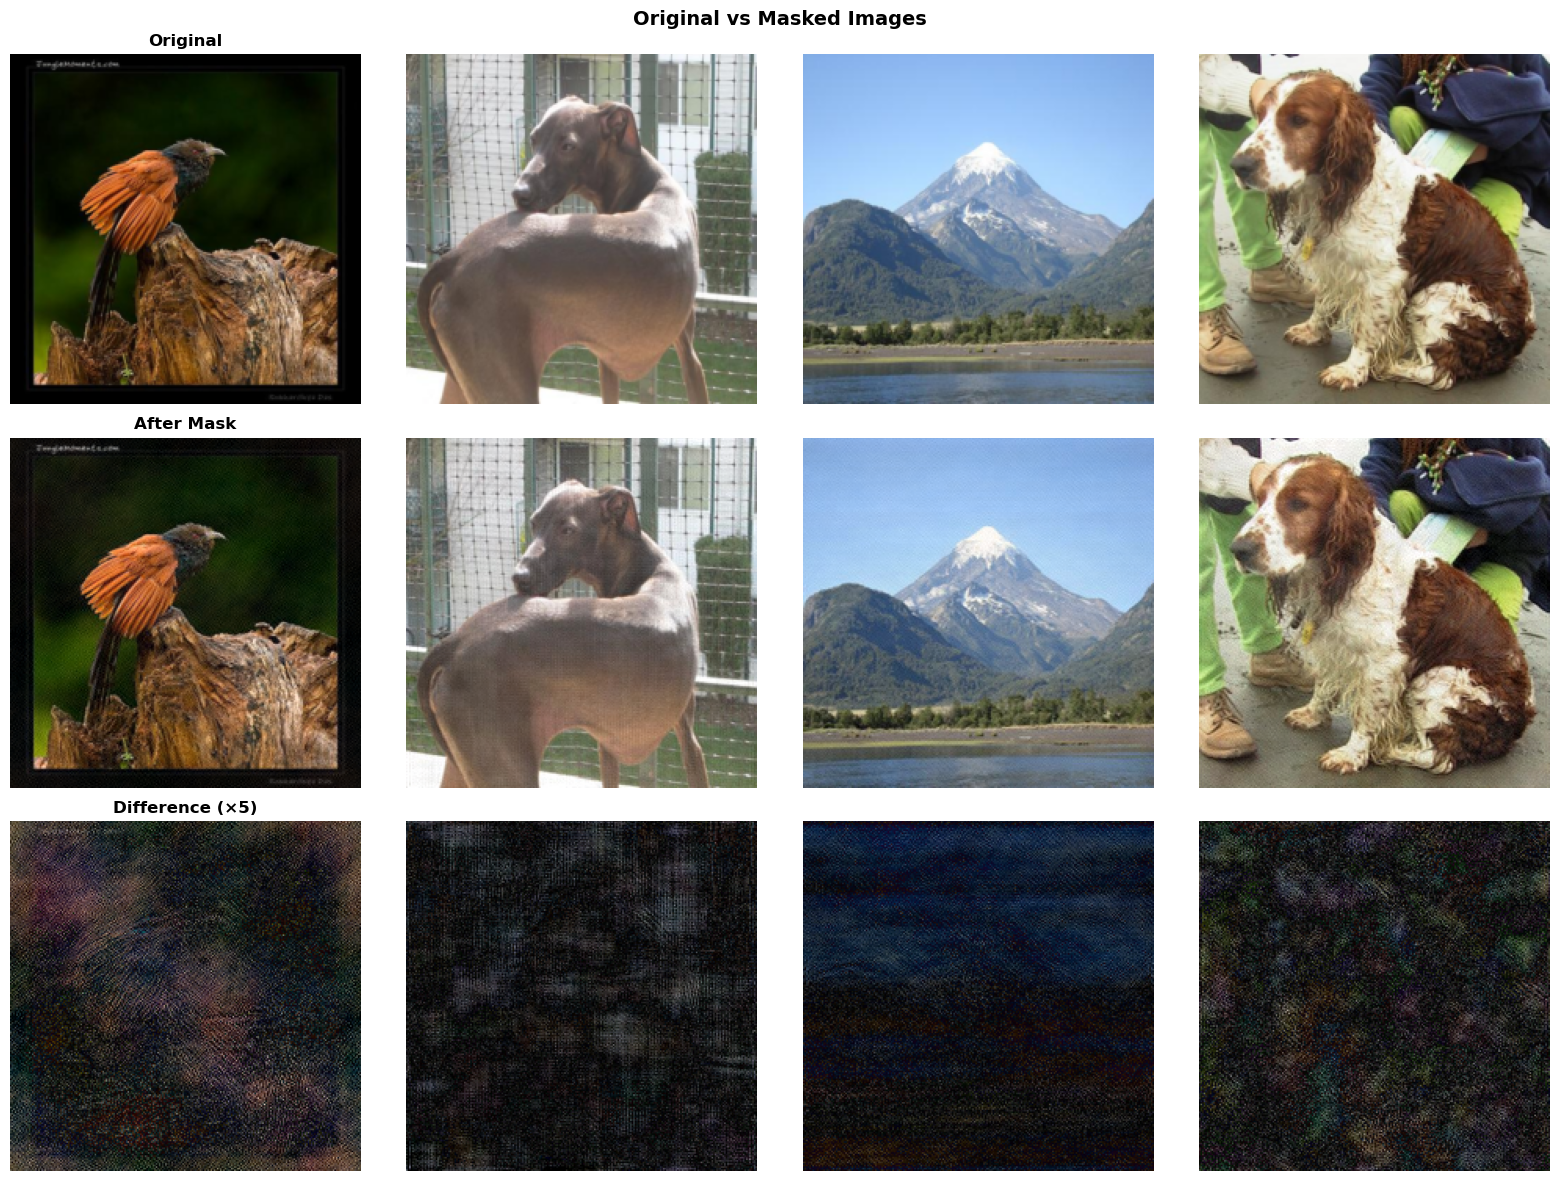

Note: Images look nearly identical, but the mask improves classification accuracy!


In [14]:
from data.dataset import get_denormalize_transform

# Get a batch of images
pipeline.eval()
sample_images, sample_labels = next(iter(dataloader))
sample_images = sample_images.to(device)

# Get reconstructions
with torch.no_grad():
    _, reconstructed = pipeline(sample_images)

# Denormalize for visualization
denormalize = get_denormalize_transform()
original = denormalize(sample_images.cpu())
reconstructed = denormalize(reconstructed.cpu())

# Plot comparisons
num_samples = 4
fig, axes = plt.subplots(3, num_samples, figsize=(16, 12))

for i in range(num_samples):
    # Original
    axes[0, i].imshow(original[i].permute(1, 2, 0).clamp(0, 1))
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original', fontsize=12, fontweight='bold')
    
    # Reconstructed
    axes[1, i].imshow(reconstructed[i].permute(1, 2, 0).clamp(0, 1))
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('After Mask', fontsize=12, fontweight='bold')
    
    # Difference (amplified)
    diff = torch.abs(original[i] - reconstructed[i]) * 5  # Amplify for visibility
    axes[2, i].imshow(diff.permute(1, 2, 0).clamp(0, 1))
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_title('Difference (×5)', fontsize=12, fontweight='bold')

plt.suptitle('Original vs Masked Images', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("Note: Images look nearly identical, but the mask improves classification accuracy!")

## 12. Save Results

In [15]:
# Create results directory
results_dir = os.path.join(PROJECT_ROOT, "experiments", "results", "alexnet")
os.makedirs(results_dir, exist_ok=True)

# Save trained mask
mask_path = os.path.join(results_dir, "learned_mask.pt")
torch.save(pipeline.freq_mask.state_dict(), mask_path)
print(f"✓ Saved learned mask to {mask_path}")

# Save training history
history_path = os.path.join(results_dir, "training_history.pt")
torch.save(history, history_path)
print(f"✓ Saved training history to {history_path}")

# Save mask visualization
plt.figure(figsize=(8, 6))
plt.imshow(learned_mask, cmap='RdBu_r', vmin=0.5, vmax=1.5)
plt.colorbar(label='Mask Weight')
plt.title('AlexNet Learned Frequency Mask', fontsize=14, fontweight='bold')
plt.xlabel('Frequency X')
plt.ylabel('Frequency Y')
mask_img_path = os.path.join(results_dir, "learned_mask.png")
plt.savefig(mask_img_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"✓ Saved mask visualization to {mask_img_path}")

# Save summary
mask_params = sum(p.numel() for p in pipeline.freq_mask.parameters())
summary = {
    'model': 'AlexNet',
    'experiment': 'Experiment 3 - 2D Learnable Frequency Mask',
    'dataset_size': len(dataset),
    'baseline_accuracy': baseline_accuracy,
    'final_accuracy': history['train_acc'][-1],
    'improvement': history['train_acc'][-1] - baseline_accuracy,
    'epochs': EPOCHS,
    'learning_rate': LEARNING_RATE,
    'mask_parameters': mask_params,
}

summary_path = os.path.join(results_dir, "summary.txt")
with open(summary_path, 'w') as f:
    f.write("AlexNet - Experiment 3 Summary\n")
    f.write("="*60 + "\n\n")
    for key, value in summary.items():
        f.write(f"{key}: {value}\n")

print(f"✓ Saved summary to {summary_path}")

print("\n" + "="*60)
print("All results saved successfully!")
print("="*60)

✓ Saved learned mask to /home/bab61wot/VIT/SIM2REAL/experiments/results/alexnet/learned_mask.pt
✓ Saved training history to /home/bab61wot/VIT/SIM2REAL/experiments/results/alexnet/training_history.pt
✓ Saved mask visualization to /home/bab61wot/VIT/SIM2REAL/experiments/results/alexnet/learned_mask.png
✓ Saved summary to /home/bab61wot/VIT/SIM2REAL/experiments/results/alexnet/summary.txt

All results saved successfully!


## Summary

This notebook trained a 2D learnable frequency mask (50,176 parameters) to identify which frequency components AlexNet relies on for classification.

**Key Findings:**
- The learned mask shows which frequencies AlexNet prefers
- Visual reconstructions look nearly identical but improve accuracy
- Results saved to `experiments/results/alexnet/`

**Next Steps:**
- Run this experiment for other architectures (VGG-16, Inception v3, ResNet-50)
- Compare learned masks across architectures
- Analyze architectural differences in frequency preferences